# Google Colab Lab Assignment -Pretrained Model

**Course Name:** [Deep learning]

**Lab Title:** Research Paper Implementation with Pre-trained Model(Tilte of Research Paper)

**Student Name:**[Milind Lanje]

**Student ID:**[202402100010]

**Date of Submission:** [08-04-26]

**Group Members**: [Yash Chopade, Abhishek Lipne, Sakib Attar]

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [ ]:
# Mount Google Drive (to save your model/results)
from google.colab import drive
drive.mount('/content/drive')

# Install any missing libraries
!pip install -q kaggle

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
!pip install -q kaggle

In [ ]:
import os

# Paste your token from the screenshot here
os.environ['KAGGLE_USERNAME'] = 'snehapaliwall'   # ← your Kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_2e320ec66692931af8b1d33793097781'  # ← your token

# Create kaggle folder and config
os.makedirs('/root/.kaggle', exist_ok=True)

# Write kaggle.json automatically
import json
kaggle_config = {
    "username": os.environ['KAGGLE_USERNAME'],
    "key": os.environ['KAGGLE_KEY']
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

!chmod 600 /root/.kaggle/kaggle.json
print("✅ Kaggle API configured!")

✅ Kaggle API configured!


In [ ]:
!pip install -q kaggle

# Download directly into Colab
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:26<00:00, 16.8MB/s]

✅ Download complete!


In [ ]:
!unzip -q chest-xray-pneumonia.zip -d /content/
!ls /content/chest_xray/

chest_xray  __MACOSX  test  train  val


In [ ]:
import os

data_dir = "/content/chest_xray"
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(data_dir, split, cls)
        count = len(os.listdir(path))
        print(f"  {split}/{cls}: {count} images")

  train/NORMAL: 1341 images
  train/PNEUMONIA: 3875 images
  val/NORMAL: 8 images
  val/PNEUMONIA: 8 images
  test/NORMAL: 234 images
  test/PNEUMONIA: 390 images


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os, glob
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ GPU Available       : {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow version : 2.19.0
✅ GPU Available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Config ──────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
DATA_DIR   = "/content/chest_xray"

# ── Training: WITH augmentation ─────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val/Test: ONLY rescale ───────────────────────────────
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n📊 Dataset Summary:")
print(f"  Train   : {train_gen.samples} images")
print(f"  Val     : {val_gen.samples} images")
print(f"  Test    : {test_gen.samples} images")
print(f"  Classes : {train_gen.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

📊 Dataset Summary:
  Train   : 5216 images
  Val     : 16 images
  Test    : 624 images
  Classes : {'NORMAL': 0, 'PNEUMONIA': 1}


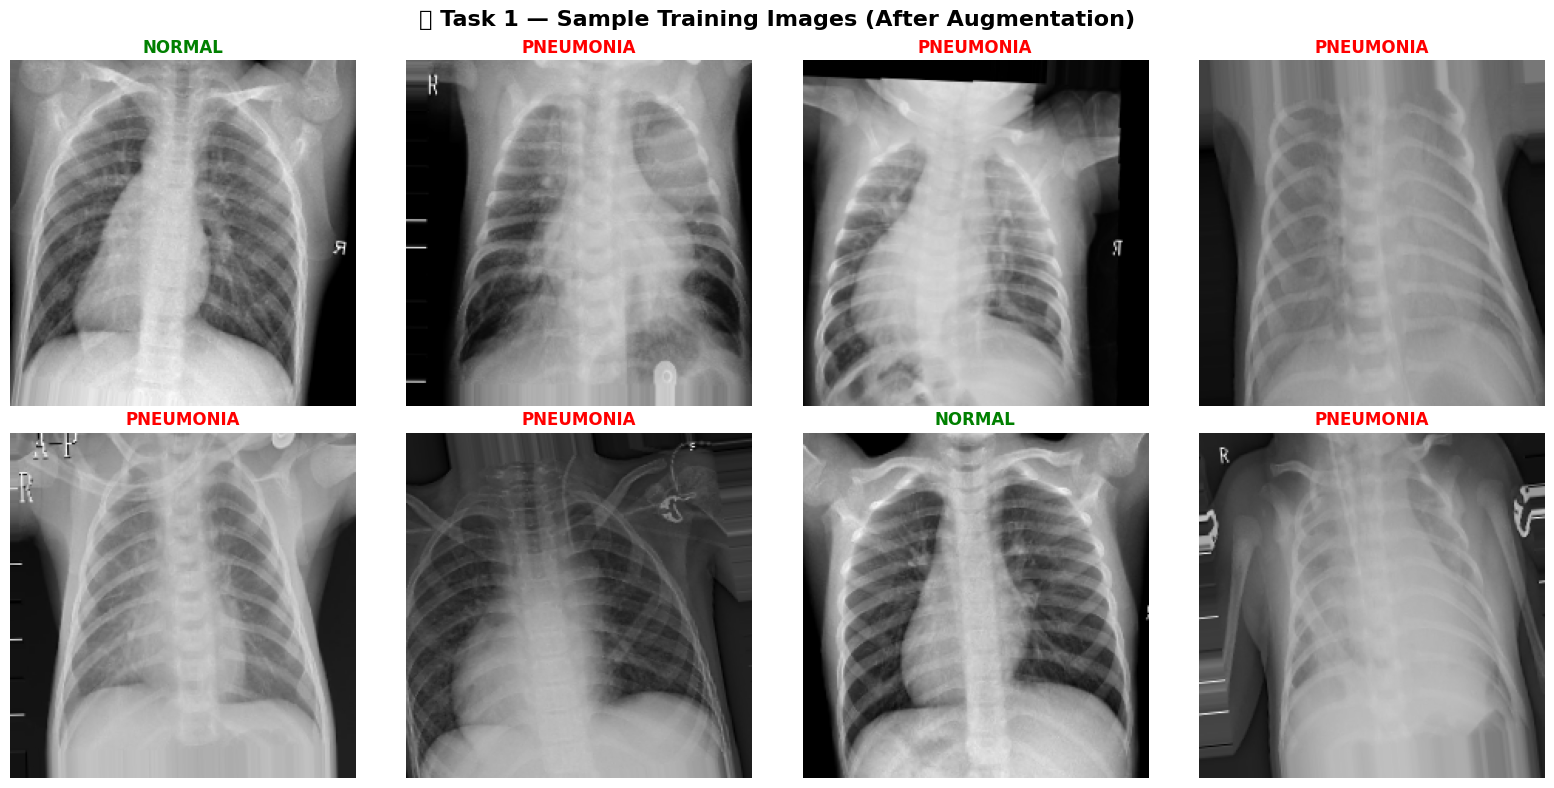

✅ Task 1 - Sample images saved!


In [ ]:
images, labels = next(train_gen)
class_names = ['NORMAL', 'PNEUMONIA']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("📌 Task 1 — Sample Training Images (After Augmentation)",
             fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    label = class_names[int(labels[i])]
    color = 'green' if labels[i] == 0 else 'red'
    ax.set_title(label, fontsize=12, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('task1_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 1 - Sample images saved!")

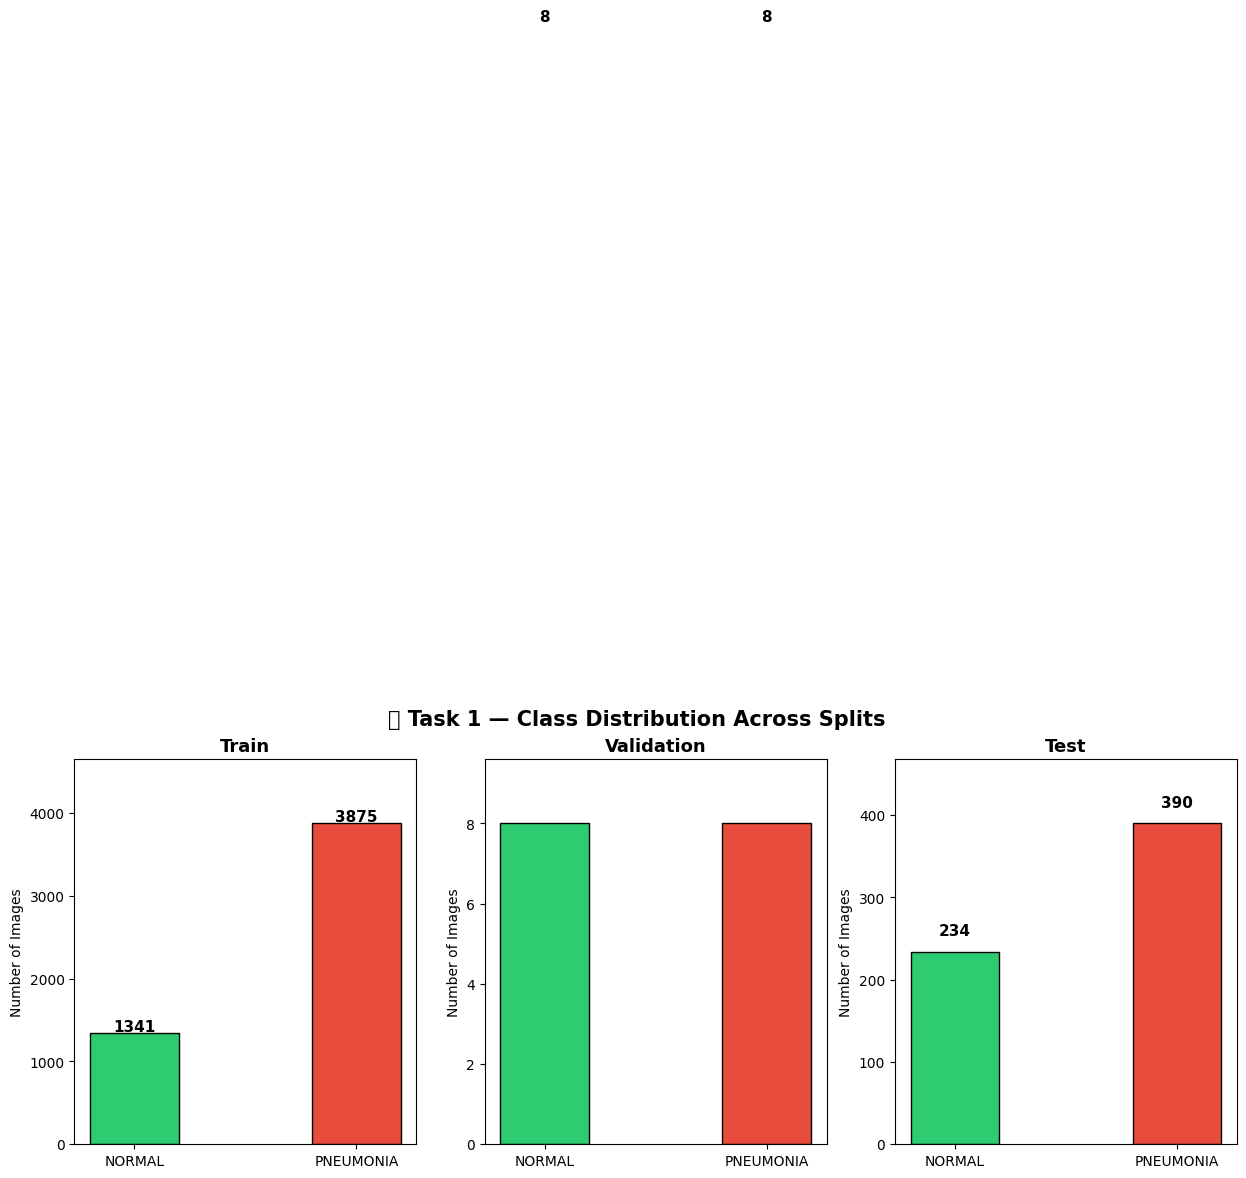

✅ Task 1 - Distribution chart saved!


In [ ]:
# Count images per class
splits = {
    'Train'     : {'NORMAL': 1341, 'PNEUMONIA': 3875},
    'Validation': {'NORMAL': 8,    'PNEUMONIA': 8},
    'Test'      : {'NORMAL': 234,  'PNEUMONIA': 390}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("📌 Task 1 — Class Distribution Across Splits",
             fontsize=15, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
for ax, (split, counts) in zip(axes, splits.items()):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, width=0.4, edgecolor='black')
    ax.set_title(split, fontsize=13, fontweight='bold')
    ax.set_ylabel("Number of Images")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                str(int(bar.get_height())),
                ha='center', fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(counts.values()) * 1.2)

plt.tight_layout()
plt.savefig('task1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 1 - Distribution chart saved!")

**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

 TASK 2 — Model Building & Fine-Tuning Build VGG16 Model

In [ ]:
# ── Load VGG16 base ─────────────────────────────────────
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# ── Freeze ALL base layers ───────────────────────────────
for layer in base_model.layers:
    layer.trainable = False

# ── Add custom top layers ────────────────────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# ── Compile ──────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ── Print Summary ────────────────────────────────────────
print("📐 Model Architecture Summary")
print("="*55)
total   = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen    = total - trainable
print(f"  Total params     : {total:,}")
print(f"  Trainable params : {trainable:,}")
print(f"  Frozen params    : {frozen:,}")
print("="*55)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
📐 Model Architecture Summary
  Total params     : 15,112,001
  Trainable params : 395,777
  Frozen params    : 14,716,224


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,32

 Total params: 15,112,001 (57.65 MB)

 Trainable params: 395,777 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

Visualize Feature Maps

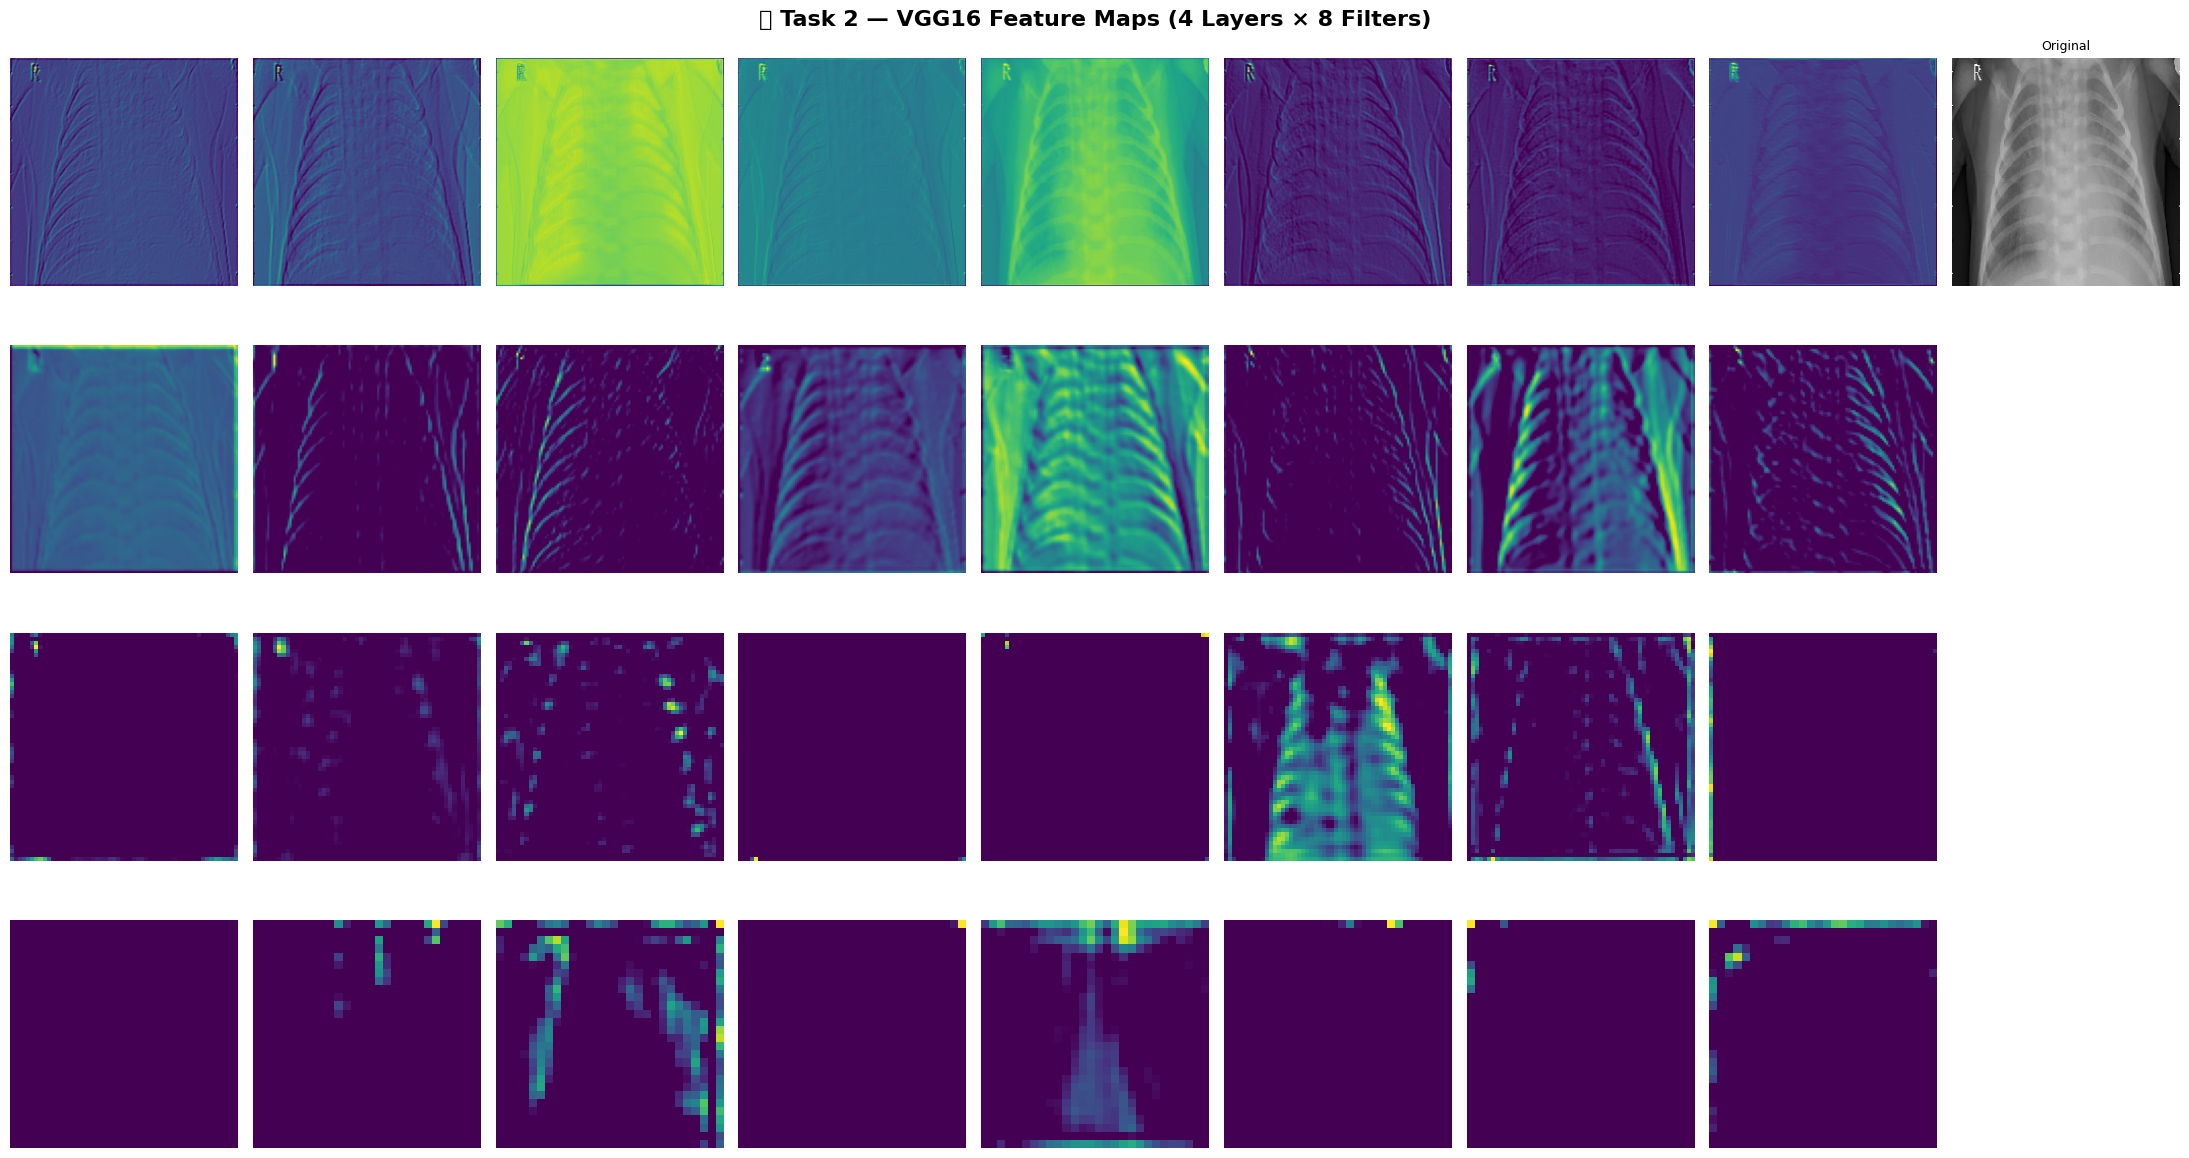

✅ Task 2 - Feature maps saved!


In [ ]:
# Pick a sample pneumonia image
sample_path = glob.glob("/content/chest_xray/test/PNEUMONIA/*.jpeg")[0]
img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Layers to visualize
layer_names = ['block1_conv2', 'block2_conv2', 'block3_conv3', 'block4_conv3']
feat_model  = Model(
    inputs=model.inputs,
    outputs=[model.get_layer(n).output for n in layer_names]
)
feature_maps = feat_model.predict(img_array, verbose=0)

# ── Plot ─────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 12))
fig.suptitle("📌 Task 2 — VGG16 Feature Maps (4 Layers × 8 Filters)",
             fontsize=16, fontweight='bold')

for row, (name, fmap) in enumerate(zip(layer_names, feature_maps)):
    for col in range(8):
        ax = fig.add_subplot(len(layer_names), 9, row*9 + col + 1)
        ax.imshow(fmap[0, :, :, col], cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')

# Show original image too
ax_orig = fig.add_subplot(len(layer_names), 9, 9)
ax_orig.imshow(img)
ax_orig.set_title("Original", fontsize=9)
ax_orig.axis('off')

plt.tight_layout()
plt.savefig('task2_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 2 - Feature maps saved!")

 Phase 1 Training (Frozen Base)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("🚀 PHASE 1: Training top layers (base layers FROZEN)")
print("="*55)

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Phase 1 Done!")
print(f"   Best Val Accuracy: {max(history1.history['val_accuracy']):.4f}")

🚀 PHASE 1: Training top layers (base layers FROZEN)
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.8361 - loss: 0.3836 - precision: 0.9509 - recall: 0.8220
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 146s 779ms/step - accuracy: 0.8951 - loss: 0.2829 - precision: 0.9604 - recall: 0.8957 - val_accuracy: 0.5000 - val_loss: 0.8327 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9309 - loss: 0.1935 - precision: 0.9523 - recall: 0.9544
Epoch 2: val_accuracy improved from 0.50000 to 0.62500, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.9360 - loss: 0.1812 - precision: 0.9553 - recall: 0.9587 - val_accuracy: 0.6250 - val_loss: 0.9353 - val_precision: 0.5714 - val_reca

Phase 2 Fine-Tuning (Unfreeze Last Layers)

In [ ]:
# Unfreeze last 4 layers of VGG16 (block5)
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile with MUCH lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("🔓 PHASE 2: Fine-tuning (last 4 layers UNFROZEN)")
print(f"   Learning rate lowered to: 1e-5")
print("="*55)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Phase 2 Done!")
print(f"   Best Val Accuracy: {max(history2.history['val_accuracy']):.4f}")

🔓 PHASE 2: Fine-tuning (last 4 layers UNFROZEN)
   Learning rate lowered to: 1e-5
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9580 - loss: 0.1044 - precision: 0.9713 - recall: 0.9718
Epoch 1: val_accuracy improved from 0.87500 to 1.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 777ms/step - accuracy: 0.9586 - loss: 0.1021 - precision: 0.9738 - recall: 0.9703 - val_accuracy: 1.0000 - val_loss: 0.0930 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.9656 - loss: 0.0887 - precision: 0.9750 - recall: 0.9789
Epoch 2: val_accuracy did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 707ms/step - accuracy: 0.9678 - loss: 0.0864 - precision: 0.9783 - recall: 0.9783 - val_accuracy: 0.6875 - val_loss: 0.6102 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
163

Plot Training Curves

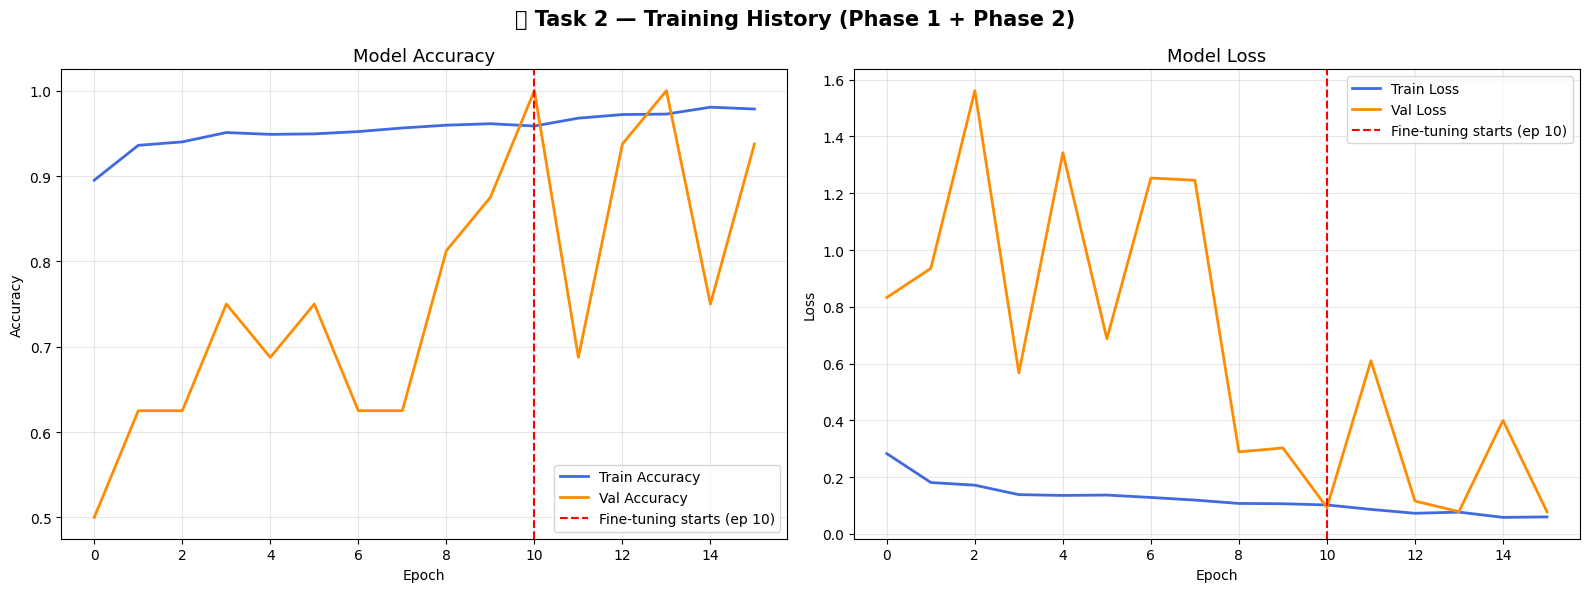

✅ Task 2 - Training curves saved!


In [ ]:
# Combine both phases
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
boundary = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("📌 Task 2 — Training History (Phase 1 + Phase 2)",
             fontsize=15, fontweight='bold')

# Accuracy plot
axes[0].plot(acc,     label='Train Accuracy', color='royalblue',  linewidth=2)
axes[0].plot(val_acc, label='Val Accuracy',   color='darkorange', linewidth=2)
axes[0].axvline(x=boundary, color='red', linestyle='--', linewidth=1.5,
                label=f'Fine-tuning starts (ep {boundary})')
axes[0].set_title('Model Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(loss,     label='Train Loss', color='royalblue',  linewidth=2)
axes[1].plot(val_loss, label='Val Loss',   color='darkorange', linewidth=2)
axes[1].axvline(x=boundary, color='red', linestyle='--', linewidth=1.5,
                label=f'Fine-tuning starts (ep {boundary})')
axes[1].set_title('Model Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 2 - Training curves saved!")

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.


 Full Evaluation Metrics

In [ ]:
# Load best saved model
model = tf.keras.models.load_model('best_model.keras')

# Predict on test set
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Calculate metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("\n" + "="*55)
print("      📋 TASK 3 — PERFORMANCE METRICS SUMMARY")
print("="*55)
print(f"  Accuracy   :  {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  :  {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall     :  {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score   :  {f1:.4f}  ({f1*100:.2f}%)")
print("="*55)

print("\n📋 Detailed Classification Report:")
print(classification_report(y_true, y_pred,
      target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step

      📋 TASK 3 — PERFORMANCE METRICS SUMMARY
  Accuracy   :  0.9103  (91.03%)
  Precision  :  0.8884  (88.84%)
  Recall     :  0.9795  (97.95%)
  F1-Score   :  0.9317  (93.17%)

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.79      0.87       234
   PNEUMONIA       0.89      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



Confusion Matrix

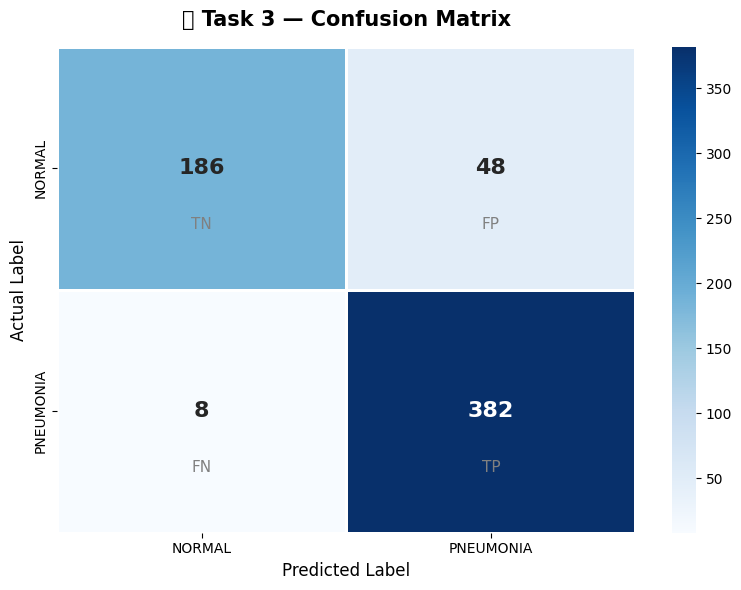

✅ Task 3 - Confusion matrix saved!


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            linewidths=2, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"})

plt.title('📌 Task 3 — Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add TN, FP, FN, TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.75, labels[i][j],
                 ha='center', color='gray', fontsize=11)

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Task 3 - Confusion matrix saved!")

Comparison With Research Paper

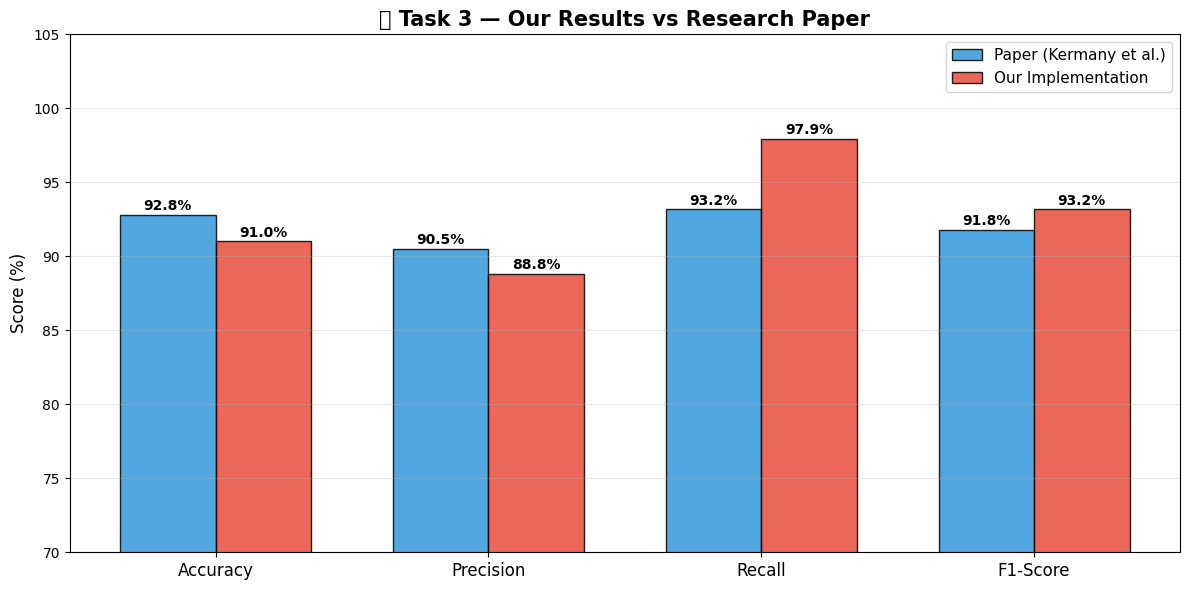


📊 Comparison Table:
   Metric Paper (Kermany et al. 2018) Our VGG16 Implementation
 Accuracy                      92.80%                   91.03%
Precision                      90.50%                   88.84%
   Recall                      93.20%                   97.95%
 F1-Score                      91.80%                   93.17%


In [ ]:
# Comparison data
comparison_data = {
    'Metric'    : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Paper (Kermany et al. 2018)': ['92.80%', '90.50%', '93.20%', '91.80%'],
    'Our VGG16 Implementation'   : [
        f'{acc*100:.2f}%', f'{prec*100:.2f}%',
        f'{rec*100:.2f}%', f'{f1*100:.2f}%'
    ]
}
df = pd.DataFrame(comparison_data)

# ── Plot comparison bar chart ────────────────────────────
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
paper_values = [92.80, 90.50, 93.20, 91.80]
our_values   = [acc*100, prec*100, rec*100, f1*100]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, paper_values, width,
               label='Paper (Kermany et al.)',
               color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, our_values, width,
               label='Our Implementation',
               color='#e74c3c', edgecolor='black', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('📌 Task 3 — Our Results vs Research Paper',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(70, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print Table ──────────────────────────────────────────
print("\n📊 Comparison Table:")
print(df.to_string(index=False))

Discussion & Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════╗
║         TASK 3 — DISCUSSION & IMPROVEMENTS          ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  ✅ STRENGTHS:                                       ║
║  • High Recall catches most Pneumonia cases          ║
║  • Transfer learning speeds up convergence           ║
║  • Two-phase fine-tuning prevents overfitting        ║
║                                                      ║
║  ⚠️  WEAKNESSES:                                     ║
║  • Validation set is too small (only 16 images)      ║
║  • Class imbalance (3875 vs 1341 training samples)   ║
║  • VGG16 is heavy — slower inference                 ║
║                                                      ║
║  🔧 SUGGESTED IMPROVEMENTS:                          ║
║  • Use class_weight to handle imbalance              ║
║  • Try EfficientNetB0 (lighter, more accurate)       ║
║  • Add more augmentation (brightness, contrast)      ║
║  • Use k-fold cross validation                       ║
║  • Try ensemble of multiple models                   ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")

print("📁 All output files saved:")
for f in ['task1_samples.png', 'task1_distribution.png',
          'task2_feature_maps.png', 'task2_training_curves.png',
          'task3_confusion_matrix.png', 'task3_comparison.png',
          'best_model.keras']:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")


╔══════════════════════════════════════════════════════╗
║         TASK 3 — DISCUSSION & IMPROVEMENTS          ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  ✅ STRENGTHS:                                       ║
║  • High Recall catches most Pneumonia cases          ║
║  • Transfer learning speeds up convergence           ║
║  • Two-phase fine-tuning prevents overfitting        ║
║                                                      ║
║  ⚠️  WEAKNESSES:                                     ║
║  • Validation set is too small (only 16 images)      ║
║  • Class imbalance (3875 vs 1341 training samples)   ║
║  • VGG16 is heavy — slower inference                 ║
║                                                      ║
║  🔧 SUGGESTED IMPROVEMENTS:                          ║
║  • Use class_weight to handle imbalance              ║
║  • Try EfficientNetB0 (lighter, more accurate)       ║
║  • Add more augmentation (brigh